<a href="https://colab.research.google.com/github/fatenmegahed/npro/blob/main/stroke-risk-prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score ,r2_score,mean_squared_error

In [32]:
df = pd.read_csv("/content/sample_data/healthcare-dataset-stroke-data.csv")
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


explore data


In [4]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [5]:
df.sample(5)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
3145,48064,Male,11.0,0,0,No,children,Rural,65.07,21.5,never smoked,0
712,63561,Male,78.0,0,0,Yes,Private,Urban,56.18,27.1,never smoked,0
4564,25476,Female,52.0,0,0,Yes,Private,Urban,83.84,35.0,Unknown,0
2479,30186,Female,5.0,0,0,No,children,Urban,81.66,17.2,Unknown,0
830,65218,Male,2.0,0,0,No,children,Rural,109.10,20.0,Unknown,0


In [33]:
df.shape

(5110, 12)

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df['age'].mean()

np.float64(43.226614481409)

In [10]:
df.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


In [58]:
df.fillna(df.mode(),inplace=True)

In [17]:
df['ever_married'].value_counts()

,count
ever_married,
Yes,3353
No,1757


In [16]:
df['gender'].value_counts()

,count
gender,
Female,2994
Male,2115
Other,1


In [35]:
df=df.drop('id',axis=1)

In [36]:
df.groupby(['ever_married','gender']).count()

age  hypertension  heart_disease  work_type  \
ever_married gender                                                 
No           Female   993           993            993        993   
             Male     763           763            763        763   
             Other      1             1              1          1   
Yes          Female  2001          2001           2001       2001   
             Male    1352          1352           1352       1352   

                     Residence_type  avg_glucose_level   bmi  smoking_status  \
ever_married gender                                                            
No           Female             993                993   964             993   
             Male               763                763   740             763   
             Other                1                  1     1               1   
Yes          Female            2001               2001  1933            2001   
             Male              1352               1352  1271            1352   

                     stroke  
ever_married gender          
No           Female     993  
             Male       763  
             Other        1  
Yes          Female    2001  
             Male      1352

In [37]:
df.groupby(['ever_married','gender'])['stroke'].agg(['sum','mean'])

sum      mean
ever_married gender               
No           Female   21  0.021148
             Male      8  0.010485
             Other     0  0.000000
Yes          Female  120  0.059970
             Male    100  0.073964

In [12]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000



**data preprocessing\**



In [38]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

In [40]:
la=LabelEncoder()
df['gender']=la.fit_transform(df['gender'])
df['ever_married']=la.fit_transform(df['ever_married'])

In [43]:
labeled=['work_type','Residence_type','smoking_status']
for i in labeled:
  df[i]=la.fit_transform(df[i])

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   int64  
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   int64  
 5   work_type          5110 non-null   int64  
 6   Residence_type     5110 non-null   int64  
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   int64  
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(8)
memory usage: 439.3 KB


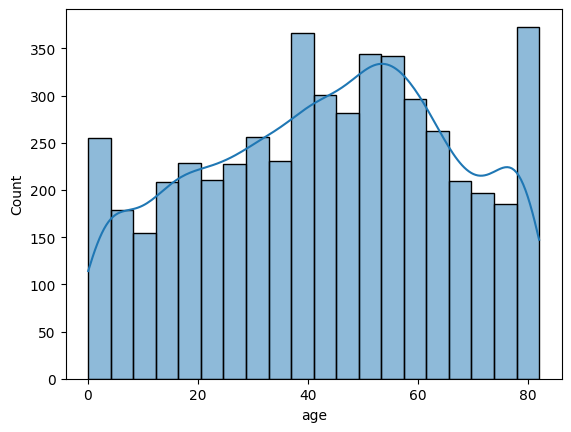

In [15]:
sns.histplot(df['age'],kde=True)
plt.show()

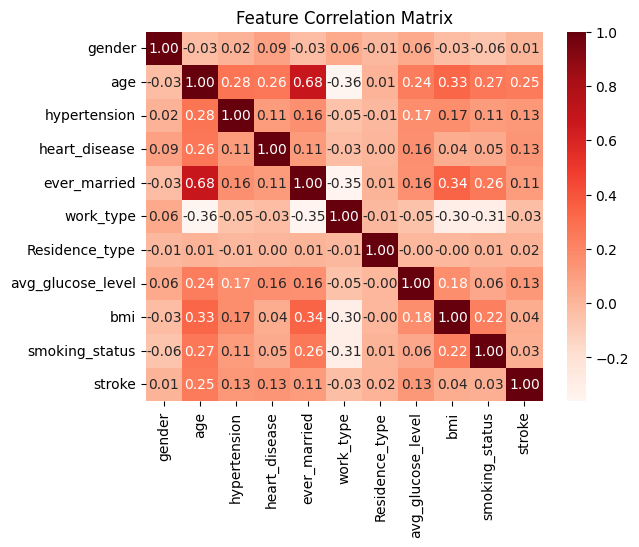

In [47]:
sns.heatmap(df.corr(),annot=True,cmap='Reds',fmt='.2f')
plt.title("Feature Correlation Matrix")
plt.show()

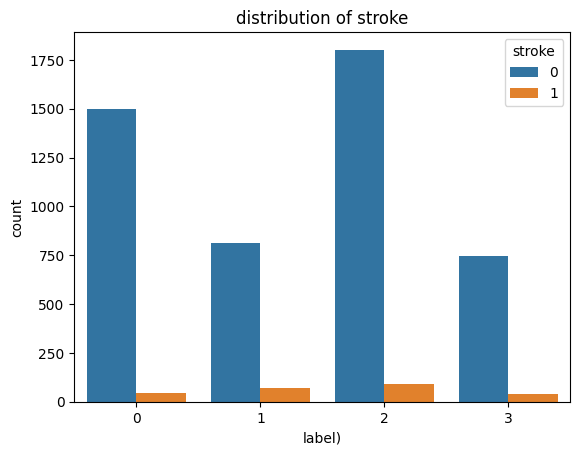

In [52]:
sns.countplot(data=df,hue='stroke',x='smoking_status')
plt.title('distribution of stroke')
plt.xlabel('label)')
plt.ylabel('count')
plt.show()

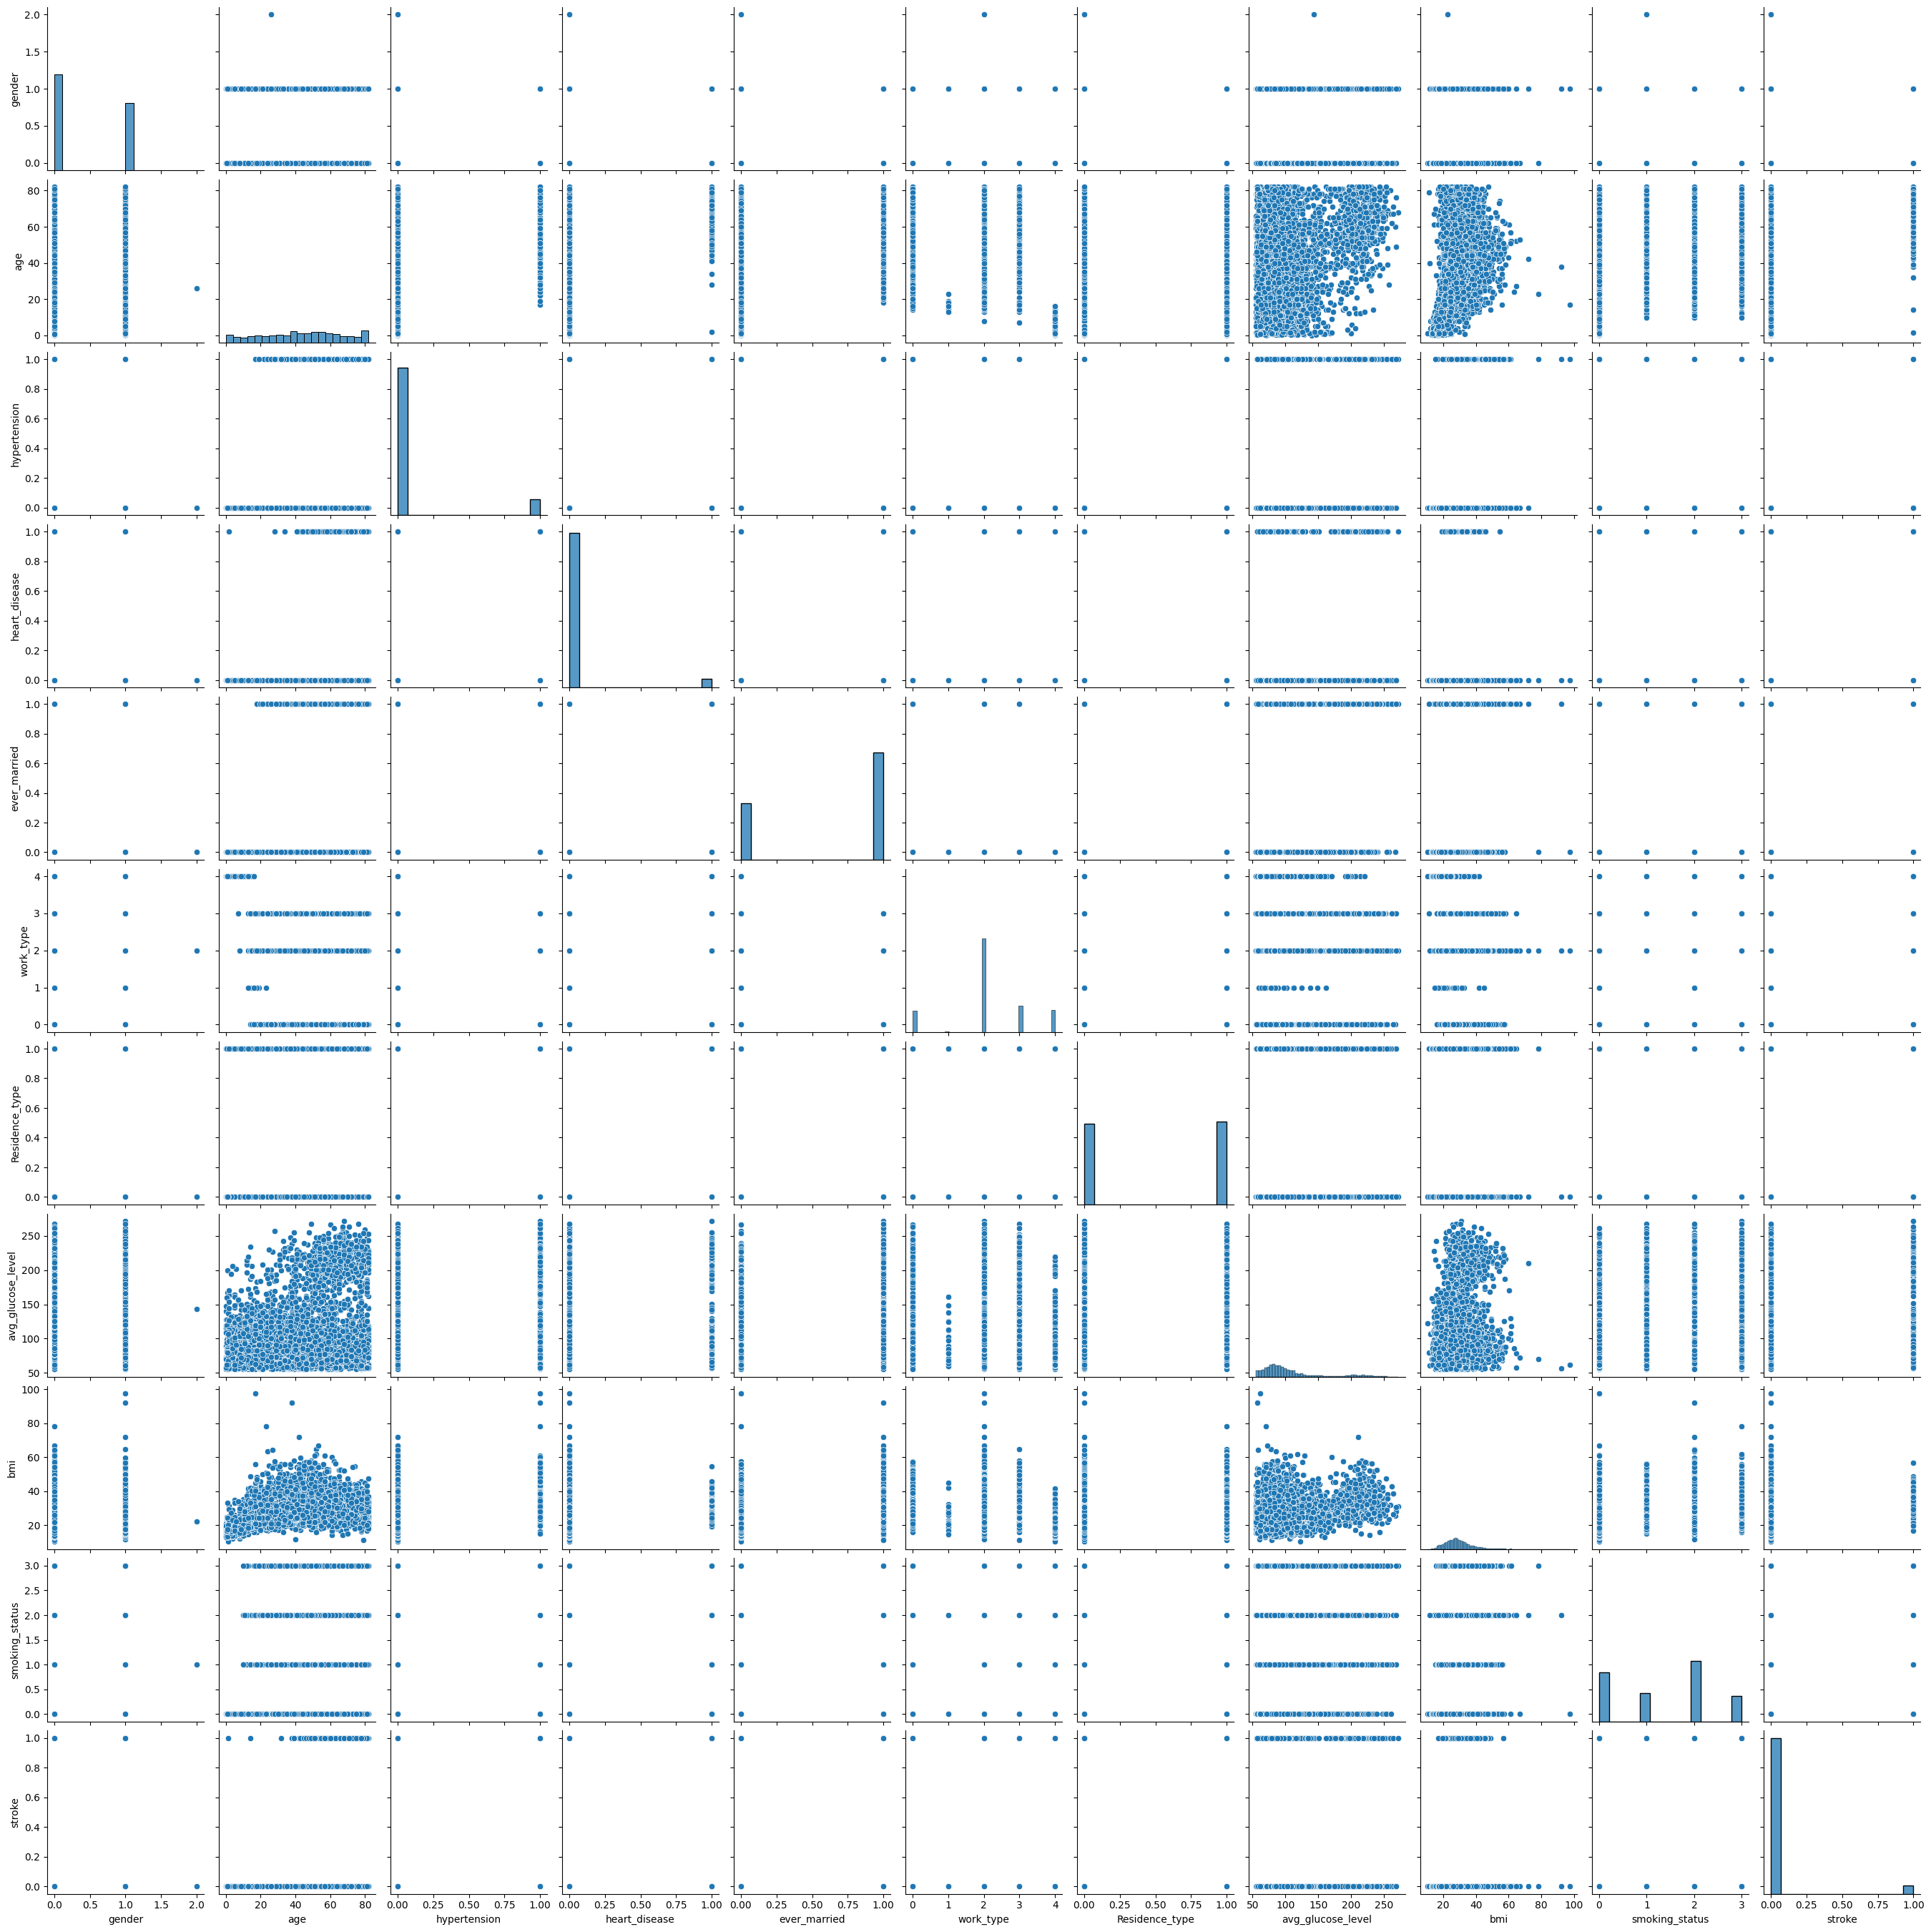

In [53]:
sns.pairplot(df)

In [55]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix


In [65]:
from sklearn.preprocessing import StandardScaler
scal=StandardScaler()
df['bmi']=scal.fit_transform(df[['bmi']])

In [56]:
x=df.drop('stroke',axis=1)
y=df['stroke']

In [72]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.2,random_state=42)
rf=RandomForestClassifier(max_depth=10,random_state=42)
rf.fit(x_train,y_train)
y_pred=rf.predict(x_test)
print('acc=',accuracy_score(y_test,y_pred))
print('clac=',classification_report(y_test,y_pred))
print('con=',confusion_matrix(y_test,y_pred))

acc= 0.9403131115459883
clac=               precision    recall  f1-score   support

           0       0.94      1.00      0.97       960
           1       1.00      0.02      0.03        62

    accuracy                           0.94      1022
   macro avg       0.97      0.51      0.50      1022
weighted avg       0.94      0.94      0.91      1022

con= [[960   0]
 [ 61   1]]


In [104]:
kn=KNeighborsClassifier(20)
bmi_mean_train=x_train['bmi'].mean()
x_train_imputed=x_train.copy()
x_test_imputed=x_test.copy()
x_train_imputed['bmi'].fillna(bmi_mean_train,inplace=True)
x_test_imputed['bmi'].fillna(bmi_mean_train,inplace=True)
x_train_scaled_knn=scal.fit_transform(x_train_imputed)
x_test_scaled_knn=scal.transform(x_test_imputed)
kn.fit(x_train_scaled_knn,y_train)
y_pred=kn.predict(x_test_scaled_knn)
print('acc=',accuracy_score(y_test,y_pred))
print('clac=',classification_report(y_test,y_pred))
print('con=',confusion_matrix(y_test,y_pred))

acc= 0.9393346379647749
clac=               precision    recall  f1-score   support

           0       0.94      1.00      0.97       960
           1       0.00      0.00      0.00        62

    accuracy                           0.94      1022
   macro avg       0.47      0.50      0.48      1022
weighted avg       0.88      0.94      0.91      1022

con= [[960   0]
 [ 62   0]]


/tmp/ipykernel_10363/3034956122.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  x_train_imputed['bmi'].fillna(bmi_mean_train,inplace=True)
/tmp/ipykernel_10363/3034956122.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=

In [83]:
lg=LogisticRegression(max_iter=100,random_state=42)
bmi_mean_train=x_train['bmi'].mean()
x_train_imputed=x_train.copy()
x_test_imputed=x_test.copy()
x_train_imputed['bmi'].fillna(bmi_mean_train,inplace=True)
x_test_imputed['bmi'].fillna(bmi_mean_train,inplace=True)
x_train_scaled_lg=scal.fit_transform(x_train_imputed)
x_test_scaled_lg=scal.transform(x_test_imputed)
lg.fit(x_train_scaled_lg,y_train)
y_pred=lg.predict(x_test_scaled_lg)

print('acc=',accuracy_score(y_test,y_pred))
print('clac=',classification_report(y_test,y_pred))
print('con=',confusion_matrix(y_test,y_pred))

acc= 0.9393346379647749
clac=               precision    recall  f1-score   support

           0       0.94      1.00      0.97       960
           1       0.00      0.00      0.00        62

    accuracy                           0.94      1022
   macro avg       0.47      0.50      0.48      1022
weighted avg       0.88      0.94      0.91      1022

con= [[960   0]
 [ 62   0]]


/tmp/ipykernel_10363/777372803.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  x_train_imputed['bmi'].fillna(bmi_mean_train,inplace=True)
/tmp/ipykernel_10363/777372803.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

In [96]:
xg=XGBClassifier(random_state=42)
bmi_mean_train=x_train['bmi'].mean()
x_train_imputed=x_train.copy()
x_test_imputed=x_test.copy()
x_train_imputed['bmi'].fillna(bmi_mean_train,inplace=True)
x_test_imputed['bmi'].fillna(bmi_mean_train,inplace=True)
x_train_scaled_lg=scal.fit_transform(x_train_imputed)
x_test_scaled_lg=scal.transform(x_test_imputed)
xg.fit(x_train_scaled_lg,y_train)
y_pred=xg.predict(x_test_scaled_lg)

print('acc=',accuracy_score(y_test,y_pred))
print('clac=',classification_report(y_test,y_pred))
print('con=',confusion_matrix(y_test,y_pred))

/tmp/ipykernel_10363/3080839812.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  x_train_imputed['bmi'].fillna(bmi_mean_train,inplace=True)
/tmp/ipykernel_10363/3080839812.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=

acc= 0.9412915851272016
clac=               precision    recall  f1-score   support

           0       0.95      0.99      0.97       960
           1       0.57      0.13      0.21        62

    accuracy                           0.94      1022
   macro avg       0.76      0.56      0.59      1022
weighted avg       0.92      0.94      0.92      1022

con= [[954   6]
 [ 54   8]]


<function matplotlib.pyplot.show(close=None, block=None)>

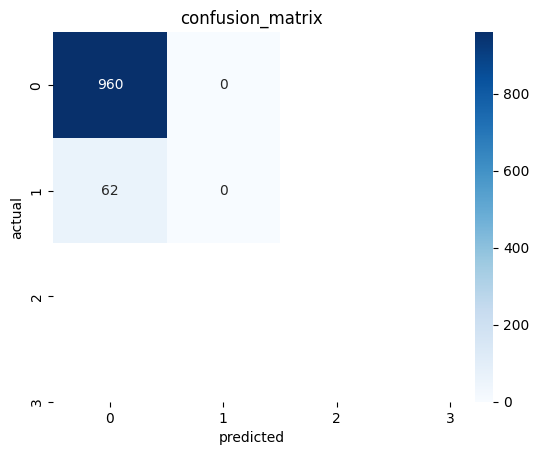

In [97]:
sns.heatmap(con,annot=True,cmap='Blues',fmt='d',xticklabels=[0,1,2,3],yticklabels=[0,1,2,3])
plt.title('confusion_matrix')
plt.xlabel('predicted')
plt.ylabel('actual')
plt.show

In [98]:
models=['LogisticRegression','KNeighborsClassifier','XGBClassifier','RandomForestClassifier']
accuracy=[0.939,0.939,.941,.940]
data=pd.DataFrame({'models':models,'accuracy':accuracy})
data

,models,accuracy
0,LogisticRegression,0.939
1,KNeighborsClassifier,0.939
2,XGBClassifier,0.941
3,RandomForestClassifier,0.940


/tmp/ipykernel_10363/2409789524.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(data=data,x='models',y='accuracy',palette='Set2')


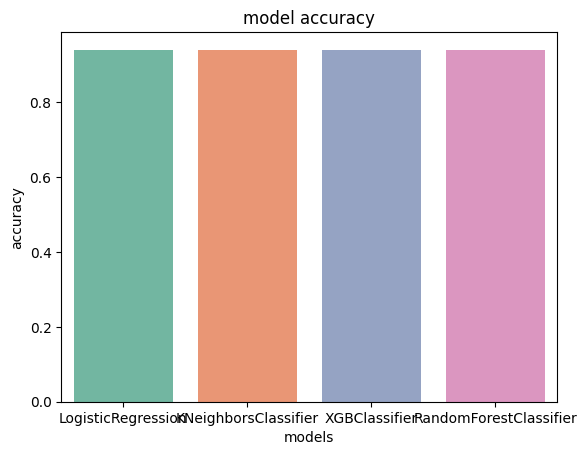

In [99]:
ax=sns.barplot(data=data,x='models',y='accuracy',palette='Set2')
plt.title('model accuracy')
plt.show()


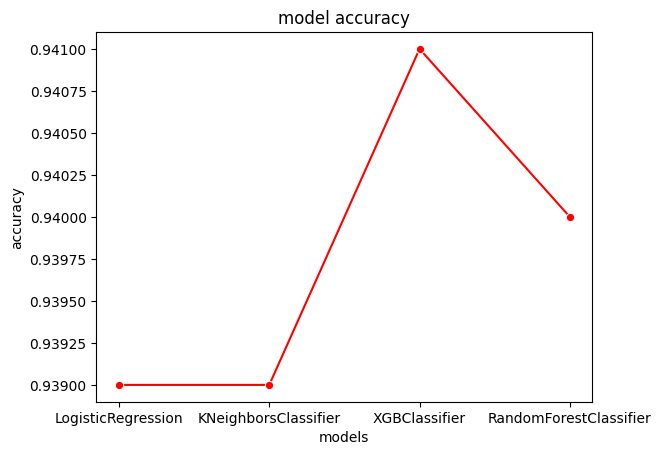

In [100]:
sns.lineplot(data=data,x='models',y='accuracy',marker='o',color='red')
plt.title('model accuracy')
plt.show()